## Import Libraries & Load Dataset

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the Excel file and parse the correct sheet
path = 'https://gitlab.crio.do/me_notebook/me_jupyter_uberanalysis/-/raw/master/Uber_ride_analysis_dataset.csv'
df = pd.read_csv(path,header=0)
df.head()

,Request id,Pickup point,Drop point,Request timestamp,Start timestamp,Drop timestamp,Trip Cost,Extra Tip,Driver id,Trip Status,Ride Type,Payment Method,Weather
0,4386.0,Majestic Bus Station,Bangalore Palace,2021-07-13 0:00:24,NaN,NaN,0.00,0.0,61.0,Trip Cancelled,UberXL,NaN,Clear
1,4387.0,Lalbagh Botanical Garden,Indiranagar,2021-07-13 0:02:14,2021-07-13 0:16:00,2021-07-13 0:26:14,111.38,0.0,17.0,Trip Completed,UberGo,Cash,Cloudy
2,4388.0,Lalbagh Botanical Garden,Kormangala Police Station,2021-07-13 0:06:34,2021-07-13 0:14:01,2021-07-13 2:01:34,89.00,25.0,21.0,Trip Completed,UberXL,Card,Clear
3,4389.0,Majestic Bus Station,ISKCON Temple,2021-07-13 0:07:31,NaN,NaN,0.00,0.0,NaN,No Cars Available,UberXL,NaN,Rainy
4,4390.0,Bangalore City Railway Station,Lalbagh Botanical Garden,2021-07-13 0:07:58,2021-07-13 0:20:21,2021-07-13 0:40:58,307.40,25.0,35.0,Trip Completed,UberGo,Cash,Rainy


## Data Cleaning

In [3]:
# Standardize column names
# Convert to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['request_id', 'pickup_point', 'drop_point', 'request_timestamp',
       'start_timestamp', 'drop_timestamp', 'trip_cost', 'extra_tip',
       'driver_id', 'trip_status', 'ride_type', 'payment_method', 'weather'],
      dtype='object')

In [4]:
# Identify missing values in each column
print(df.isnull().sum())

request_id            200
pickup_point          200
drop_point            200
request_timestamp     200
start_timestamp      1850
drop_timestamp       1850
trip_cost             200
extra_tip             200
driver_id             975
trip_status           200
ride_type             200
payment_method       1850
weather               200
dtype: int64


In [5]:
# Drop rows with missing trip status or trip cost
df = df.dropna(subset=['trip_status', 'trip_cost'])

In [6]:
# Fill missing payment method with mode
df['payment_method'].fillna(df['payment_method'].mode()[0], inplace=True)

/tmp/ipykernel_140/4126109900.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['payment_method'].fillna(df['payment_method'].mode()[0], inplace=True)


In [7]:
# Fill missing driver ID with -1 (indicates unassigned)
df['driver_id'].fillna(-1, inplace=True)

/tmp/ipykernel_140/1066594594.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['driver_id'].fillna(-1, inplace=True)


In [8]:
#  Handle timestamps conditionally
# Drop rows where timestamps are missing only for 'Trip Completed'
df = df[~((df['trip_status'] == 'Trip Completed') & (df['start_timestamp'].isna() | df['drop_timestamp'].isna()))]

In [9]:
# Identify missing values in each column
print(df.isnull().sum())

request_id              0
pickup_point            0
drop_point              0
request_timestamp       0
start_timestamp      1650
drop_timestamp       1650
trip_cost               0
extra_tip               0
driver_id               0
trip_status             0
ride_type               0
payment_method          0
weather                 0
dtype: int64


In [10]:
# Convert date columns to datetime
date_columns = ['request_timestamp', 'start_timestamp', 'drop_timestamp']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [11]:
#  List all numeric columns
numeric_columns = df.select_dtypes(include='number').columns.tolist()
print(numeric_columns)

['request_id', 'trip_cost', 'extra_tip', 'driver_id']


## Outlier Detection and Treatment

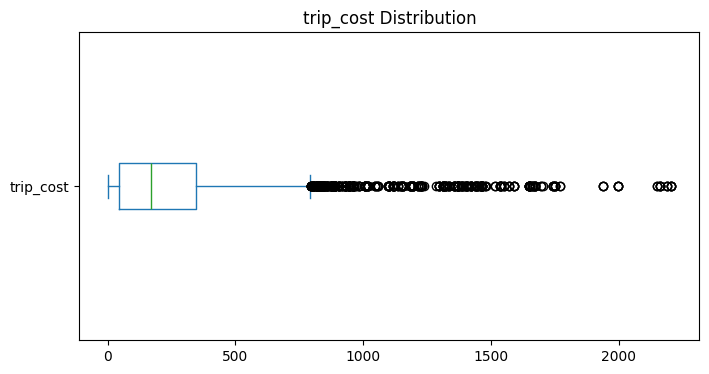

In [12]:
# Plot boxplot for trip cost
plt.figure(figsize=(8, 4))
df['trip_cost'].plot(kind='box', vert=False)
plt.title('trip_cost Distribution')
plt.show()

In [13]:
# Detect and cap outliers in trip cost using IQR
Q1 = df['trip_cost'].quantile(0.25)
Q3 = df['trip_cost'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df['trip_cost'] = np.where(df['trip_cost'] > upper_bound, upper_bound, df['trip_cost'])

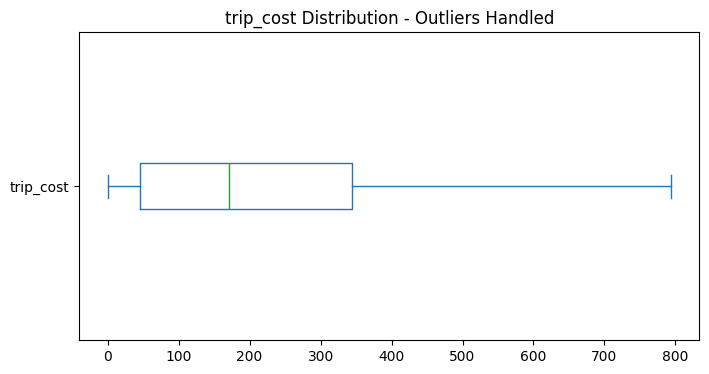

In [14]:
# Plot boxplot for trip cost
plt.figure(figsize=(8, 4))
df['trip_cost'].plot(kind='box', vert=False)
plt.title('trip_cost Distribution - Outliers Handled')
plt.show()

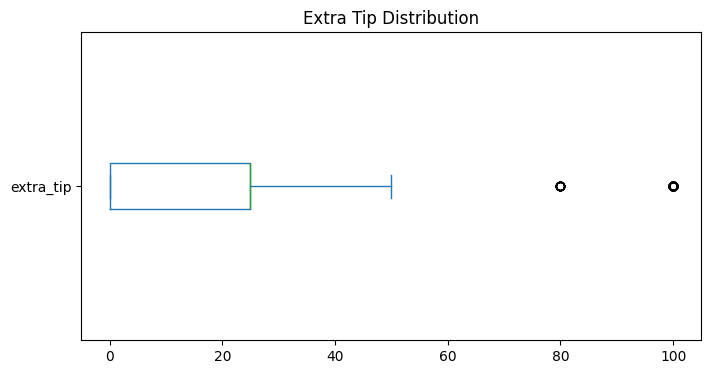

In [15]:
#  Repeat for extra tip
plt.figure(figsize=(8, 4))
df['extra_tip'].plot(kind='box', vert=False)
plt.title('Extra Tip Distribution')
plt.show()


## 📊 Exploratory Data Analysis (EDA)

Now that the data cleaning is done, let's perform EDA to understand the dataset better and derive insights.


## 1. Dataset Overview

In [16]:
# TODO 1.1 Understand the shape of the dataset
df.shape

(6745, 13)

In [17]:
# TODO 1.2 Understand the datatypes of the columns
df.dtypes

request_id                  float64
pickup_point                 object
drop_point                   object
request_timestamp    datetime64[ns]
start_timestamp      datetime64[ns]
drop_timestamp       datetime64[ns]
trip_cost                   float64
extra_tip                   float64
driver_id                   float64
trip_status                  object
ride_type                    object
payment_method               object
weather                      object
dtype: object

## 2. Trip Status Breakdown

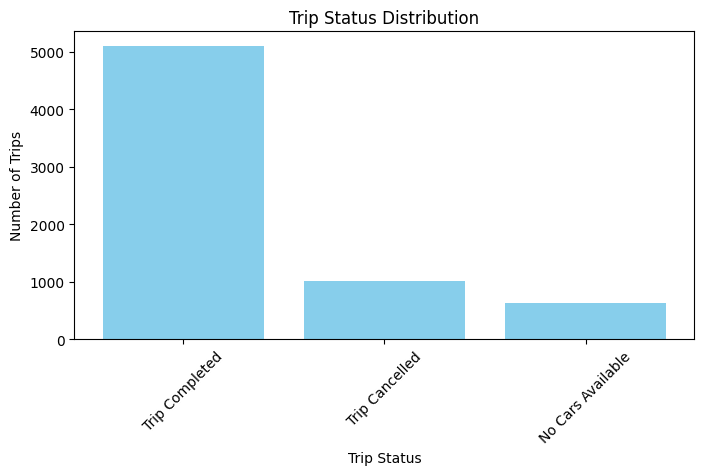

In [18]:
# TODO 2: Plot the value_counts for different trip statuses
trip_counts= df['trip_status'].value_counts()
plt.figure(figsize=(8,4))
plt.bar(trip_counts.index, trip_counts.values, color='skyblue')
plt.xlabel("Trip Status")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.title("Trip Status Distribution")
plt.show()

## 3. Trip Cost Distribution

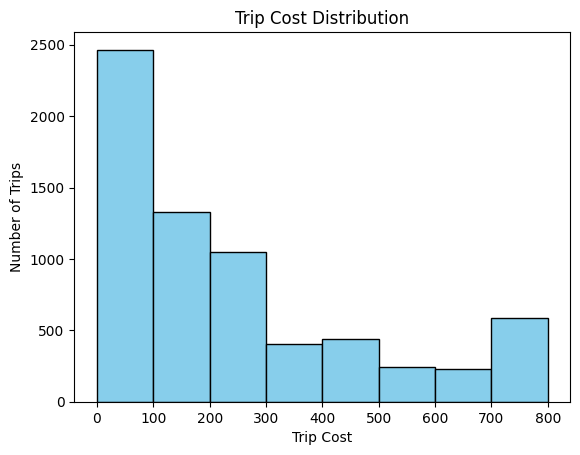

In [19]:
# TODO 3: Plot Trip Cost Distribution
# Define bin edges at intervals of 100, starting from 0 up to the maximum trip cost
# Plot the histogram with the specified bins
# Turn off grid
bins=np.arange(0, df['trip_cost'].max() + 100, 100)
plt.hist(df['trip_cost'],bins=bins,color='skyblue',edgecolor='black')
plt.title("Trip Cost Distribution")
plt.xlabel("Trip Cost")
plt.ylabel("Number of Trips")
plt.grid(False)  # Turn off gridlines
plt.show()

## 4. Analyze Payment Methods

In [29]:
# TODO 4
# Analyze trip costs across payment methods by calculating the average, median, and number of trips for each method,
# and sort the results to highlight the most expensive payment types on average

trip_cost_summary =(
    df.groupby('payment_method')['trip_cost'].agg(['mean','median','count'])
                                                                  .sort_values(by='mean',ascending=False))
print(trip_cost_summary)

                      mean  median  count
payment_method                           
Card            316.517799  231.50   1708
UPI             315.056717  233.75   1663
Cash            156.880047   45.00   3374


## 5. Trip Duration Analysis


In [30]:
# TODO 5.1 : Compute the trip duration in minutes by taking the difference between drop and start timestamps
df['trip_duration']=(df['drop_timestamp']-df['start_timestamp']).dt.total_seconds()/60

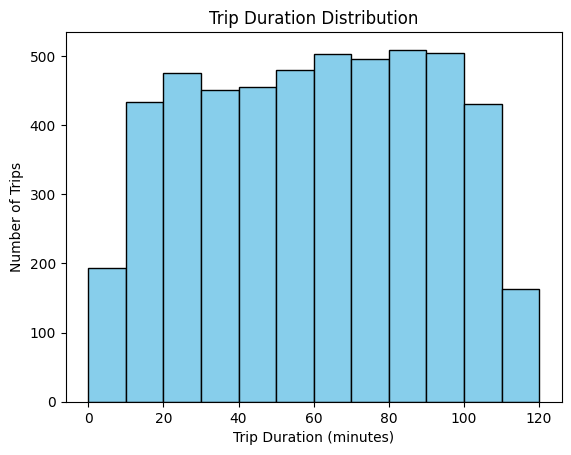

In [31]:
# TODO 5.2 : Plot distribution of trip duration
# Define bins with a fixed size (e.g., every 10 minutes)
# Grid should not be visible
bins = range(0, int(df['trip_duration'].max()) + 10, 10)

plt.hist(df['trip_duration'], bins=bins, color='skyblue', edgecolor='black')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.title('Trip Duration Distribution')
plt.grid(False)

plt.show()